# Programming in Python II - Final Coding Project

Author:

Student ID: K12341567

Save this file under a file name in the format k+matriculation_number.ipynb, e.g. *k1234567.ipynb*. Remember that for final submission all code cells must run without errors and all cells have to be evaluated.

The code cells are a basic scaffold - you can of course add new code cells if necessary. However, stick to the overall structure of the template to facilitate grading. Ensure to comment your code and structure it reasonably.

In [1]:
# This is just a minimum setup for reproducibility. Add more libraries as required.

import numpy as np
import torch
import matplotlib.pyplot as plt
import os
import pandas as pd

import torchvision

from torchvision import transforms

from torch.utils.data import Dataset, DataLoader

import torch.nn as nn

import torch.optim as optim

# Setting device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.backends.mps.is_available():
    device = torch.device("mps")

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

In [2]:
# checking successful setup
print(f"Using device: {device}")

Using device: mps


In [3]:
# For visualization in Jupyter notebooks
%matplotlib inline

In [4]:
# Set working directory to the project folder
# os.chdir("my_project_folder")  # Change this to your project folder path
print(f"Current working directory: {os.getcwd()}")

Current working directory: /Users/tarannomgholami/Desktop/k12341567_final_project


In [5]:
# creating folder 'assets' if necessary
os.makedirs("assets", exist_ok=True)

## Data Handling and Pre-Processing

In [6]:
# your code goes here (preprocess function)
def preprocess(data_folder):

    classes = sorted([
    folder for folder in os.listdir(data_folder)
    if not folder.startswith(".")
])

    label_dict = {}

    for idx, class_name in enumerate(classes):
        label_dict[class_name] = idx

    rows = []

    for class_name in classes:

        class_folder = os.path.join(data_folder, class_name)

        if not os.path.isdir(class_folder):
            continue

        for file_name in os.listdir(class_folder):

            if file_name.lower().endswith((".jpg", ".jpeg", ".png")):

                rows.append({
                    "folder": class_folder,
                    "file_name": file_name,
                    "label": label_dict[class_name],
                    "class_name": class_name
                })

    df = pd.DataFrame(rows)

    return df, label_dict

In [7]:
# checking successful dataframe loading

# uncomment after preprocessing the dataset and adapt the variable name
# print(f"Length of dataset: {len(dataset)}") # Should be 10000
dataset, label_dict = preprocess("data")

print("Length of dataset:", len(dataset))

dataset.head()

Length of dataset: 10000


,folder,file_name,label,class_name
0,data/AnnualCrop,AnnualCrop_1372.jpg,0,AnnualCrop
1,data/AnnualCrop,AnnualCrop_1366.jpg,0,AnnualCrop
2,data/AnnualCrop,AnnualCrop_2109.jpg,0,AnnualCrop
3,data/AnnualCrop,AnnualCrop_1428.jpg,0,AnnualCrop
4,data/AnnualCrop,AnnualCrop_2874.jpg,0,AnnualCrop


In [8]:
# your code goes here (splitting train/validation datasets
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    dataset,
    test_size=0.2,
    stratify=dataset["label"],
    random_state=42
)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))

train_df.head()

Training samples: 8000
Validation samples: 2000


,folder,file_name,label,class_name
4670,data/Industrial,Industrial_1176.jpg,4,Industrial
1755,data/Forest,Forest_1041.jpg,1,Forest
5579,data/Pasture,Pasture_1045.jpg,5,Pasture
5249,data/Pasture,Pasture_1701.jpg,5,Pasture
9190,data/SeaLake,SeaLake_234.jpg,9,SeaLake


## Exploratory Data Analysis (EDA)

In [9]:
from PIL import Image

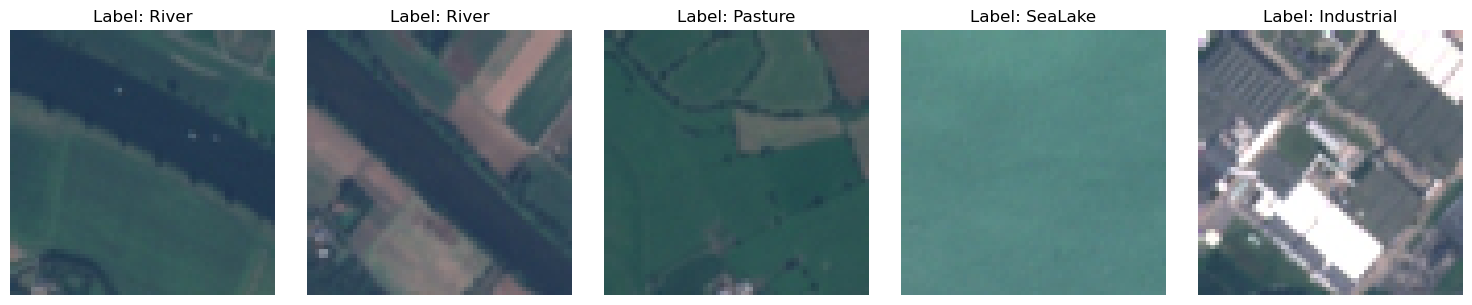

In [10]:
# your code goes here (show_samples)
def show_samples(df: pd.DataFrame, num_samples: int = 5) -> None:
    os.makedirs("assets/plots", exist_ok=True)

    samples = df.sample(num_samples, random_state=42)

    fig, axes = plt.subplots(1, num_samples, figsize=(3 * num_samples, 3))

    if num_samples == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, samples.iterrows()):
        image_path = os.path.join(row["folder"], row["file_name"])
        image = Image.open(image_path)

        ax.imshow(image)
        ax.set_title(f"Label: {row['class_name']}")
        ax.axis("off")

    plt.tight_layout()
    plt.savefig("assets/plots/random_samples.png")
    plt.show()

show_samples(train_df)


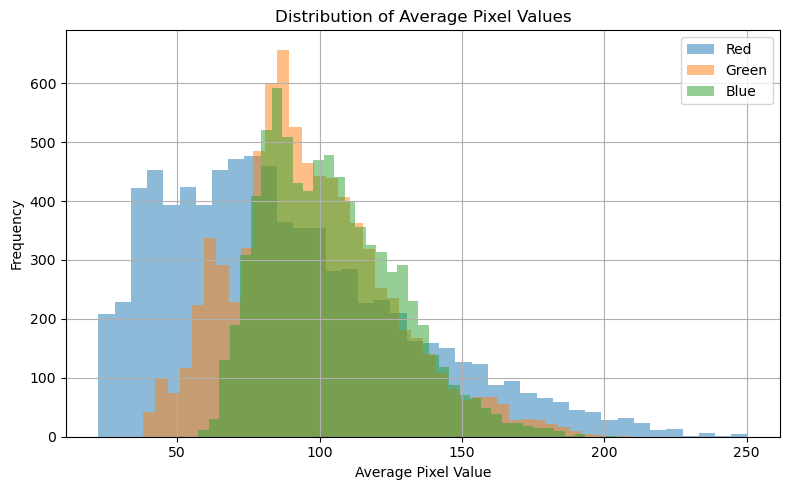

In [11]:
# your code goes here (average_pixel_plot)
def average_pixel_plot(df: pd.DataFrame) -> None:
    os.makedirs("assets/plots", exist_ok=True)

    red_values = []
    green_values = []
    blue_values = []

    for _, row in df.iterrows():
        image_path = os.path.join(row["folder"], row["file_name"])
        image = Image.open(image_path).convert("RGB")
        image_array = np.array(image)

        red_values.append(image_array[:, :, 0].mean())
        green_values.append(image_array[:, :, 1].mean())
        blue_values.append(image_array[:, :, 2].mean())

    plt.figure(figsize=(8, 5))
    plt.hist(red_values, bins=40, alpha=0.5, label="Red")
    plt.hist(green_values, bins=40, alpha=0.5, label="Green")
    plt.hist(blue_values, bins=40, alpha=0.5, label="Blue")

    plt.title("Distribution of Average Pixel Values")
    plt.xlabel("Average Pixel Value")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig("assets/plots/average_pixel_distribution.png")
    plt.show()

average_pixel_plot(train_df)

<Figure size 1200x600 with 0 Axes>

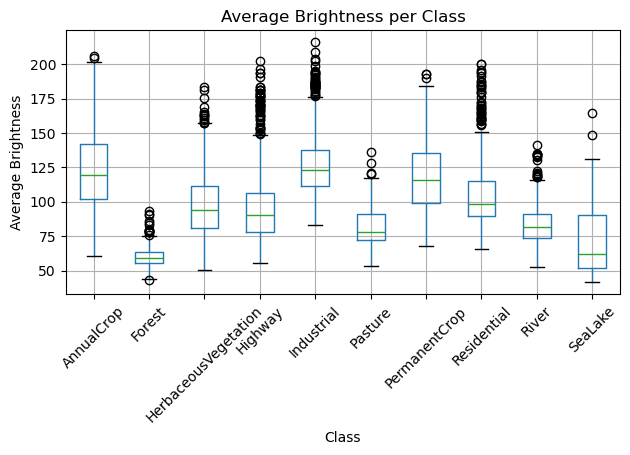

In [12]:
# your code goes here (average_brightness_per_class)
def average_brightness_per_class(df: pd.DataFrame) -> None:
    os.makedirs("assets/plots", exist_ok=True)

    rows = []

    for _, row in df.iterrows():
        image_path = os.path.join(row["folder"], row["file_name"])
        image = Image.open(image_path).convert("RGB")
        image_array = np.array(image)

        brightness = image_array.mean()

        rows.append({
            "class_name": row["class_name"],
            "brightness": brightness
        })

    brightness_df = pd.DataFrame(rows)

    plt.figure(figsize=(12, 6))
    brightness_df.boxplot(column="brightness", by="class_name", rot=45)

    plt.title("Average Brightness per Class")
    plt.suptitle("")
    plt.xlabel("Class")
    plt.ylabel("Average Brightness")

    plt.tight_layout()
    plt.savefig("assets/plots/average_brightness.png")
    plt.show()

average_brightness_per_class(train_df)

## CNN Implementation and Training

### Dataset class

In [13]:
# your code goes here
class SatelliteDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image_path = os.path.join(
            row["folder"],
            row["file_name"]
        )

        image = Image.open(image_path).convert("RGB")

        label = row["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

### Data Loaders

In [14]:
# your code goes here
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

batch_size = 64

train_dataset = SatelliteDataset(train_df, transform=train_transform)
val_dataset = SatelliteDataset(val_df, transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 125
Validation batches: 32


### Model Architecture

In [15]:
# your code goes here
import torch.nn as nn

class CNNModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = CNNModel(num_classes=len(label_dict))
model = model.to(device)

print(model)

CNNModel(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


### Training Loop

In [16]:
# your code goes here
os.makedirs("assets/weights", exist_ok=True)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

num_epochs = 30

train_losses = []
val_losses = []
val_accuracies = []

best_val_accuracy = 0.0
best_model_path = "assets/weights/best_model.pth"

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).long()

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device).long()

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_val_loss / len(val_loader)
    val_accuracy = correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), best_model_path)

    print(f"Epoch {epoch + 1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.4f}")
    print("-" * 30)

print("Best validation accuracy:", best_val_accuracy)

Epoch 1/30
Train Loss: 1.3980
Validation Loss: 1.0031
Validation Accuracy: 0.6420
------------------------------
Epoch 2/30
Train Loss: 0.9049
Validation Loss: 0.8429
Validation Accuracy: 0.6980
------------------------------
Epoch 3/30
Train Loss: 0.7602
Validation Loss: 0.8332
Validation Accuracy: 0.7105
------------------------------
Epoch 4/30
Train Loss: 0.7120
Validation Loss: 0.7017
Validation Accuracy: 0.7355
------------------------------
Epoch 5/30
Train Loss: 0.6371
Validation Loss: 0.7586
Validation Accuracy: 0.7245
------------------------------
Epoch 6/30
Train Loss: 0.6022
Validation Loss: 0.4839
Validation Accuracy: 0.8240
------------------------------
Epoch 7/30
Train Loss: 0.5463
Validation Loss: 0.4489
Validation Accuracy: 0.8375
------------------------------
Epoch 8/30
Train Loss: 0.5196
Validation Loss: 0.9833
Validation Accuracy: 0.7460
------------------------------
Epoch 9/30
Train Loss: 0.4667
Validation Loss: 0.6576
Validation Accuracy: 0.7910
--------------

## Model Evaluation

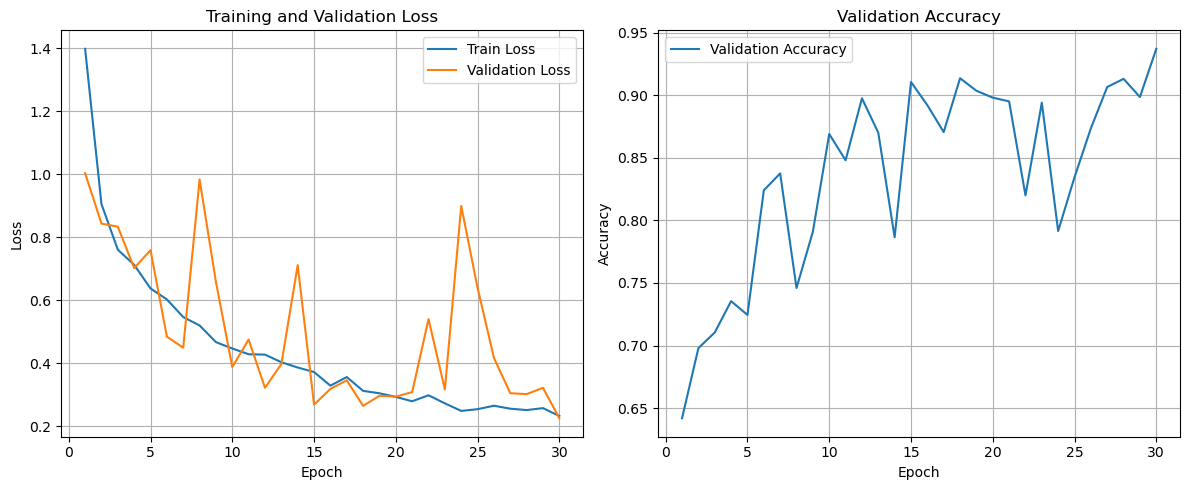

In [17]:
# your code goes here (plot_training_curves)
def plot_training_curves():
    epochs = range(1, len(train_losses) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(epochs, train_losses, label="Train Loss")
    axes[0].plot(epochs, val_losses, label="Validation Loss")
    axes[0].set_title("Training and Validation Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(epochs, val_accuracies, label="Validation Accuracy")
    axes[1].set_title("Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_training_curves()

<Figure size 1000x1000 with 0 Axes>

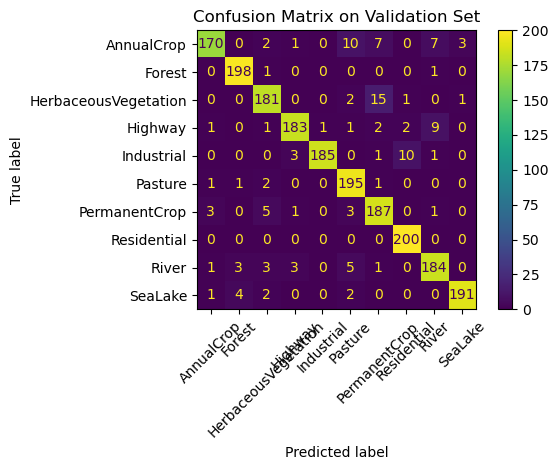

In [18]:
# your code goes here (plot_confusion_matrix)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix():
    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device).long()

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    cm = confusion_matrix(all_labels, all_predictions)

    display_labels = list(label_dict.keys())

    plt.figure(figsize=(10, 10))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=display_labels
    )
    disp.plot(xticks_rotation=45)
    plt.title("Confusion Matrix on Validation Set")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix()

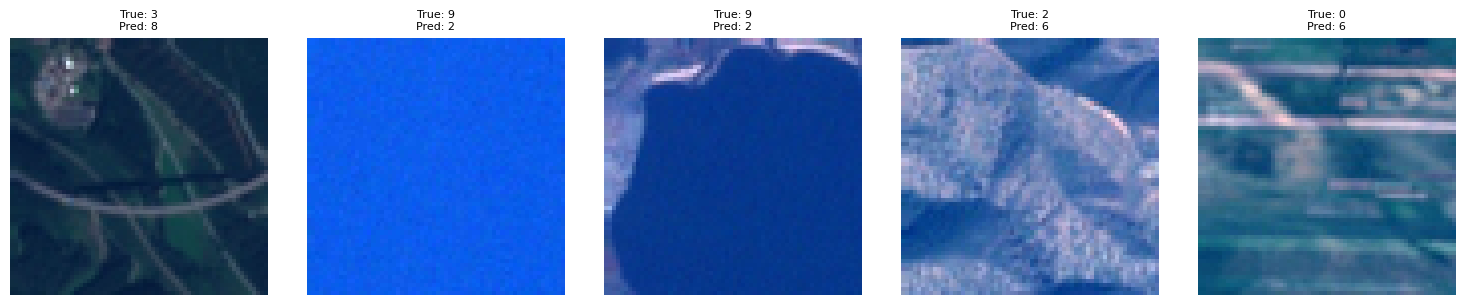

In [19]:
# your code goes here (plot_misclassified_samples)
def plot_misclassified_samples():
    model.eval()

    wrong_samples = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device).long()

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            for i in range(len(labels)):
                if preds[i] != labels[i]:
                    wrong_samples.append(
                        (
                            images[i].cpu(),
                            labels[i].cpu().item(),
                            preds[i].cpu().item()
                        )
                    )

                if len(wrong_samples) >= 5:
                    break

            if len(wrong_samples) >= 5:
                break

    fig, axes = plt.subplots(1, 5, figsize=(15, 3))

    for ax, (img, true_label, pred_label) in zip(axes, wrong_samples):
        img = img.permute(1, 2, 0).numpy()

        img = (img - img.min()) / (img.max() - img.min())

        ax.imshow(img)

        ax.set_title(
            f"True: {true_label}\nPred: {pred_label}",
            fontsize=8
        )

        ax.axis("off")

    plt.tight_layout()
    plt.show()

plot_misclassified_samples()

### Test Set

In [20]:
# your code goes here (preprocess_test_data)
def preprocess_test(data_folder: str) -> pd.DataFrame:
    rows = []

    for file_name in os.listdir(data_folder):
        if file_name.lower().endswith((".jpg", ".jpeg", ".png")):
            rows.append({
                "folder": data_folder,
                "file_name": file_name
            })

    test_df = pd.DataFrame(rows)
    test_df = test_df.sort_values("file_name").reset_index(drop=True)

    return test_df


test_df = preprocess_test("public_test_data")

print(test_df.head())
print("Number of test images:", len(test_df))

             folder file_name
0  public_test_data  1001.jpg
1  public_test_data  1002.jpg
2  public_test_data  1008.jpg
3  public_test_data   101.jpg
4  public_test_data  1034.jpg
Number of test images: 1980


In [21]:
# your code goes here (create dataset and dataloader)
class TestSatelliteDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image_path = os.path.join(
            row["folder"],
            row["file_name"]
        )

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, row["file_name"]


test_dataset = TestSatelliteDataset(test_df, transform=val_transform)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Test batches:", len(test_loader))

Test batches: 31


In [22]:
# your code goes here (evaluate model on test set)
model.eval()

test_file_names = []
test_predictions = []

with torch.no_grad():
    for images, file_names in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        test_file_names.extend(file_names)
        test_predictions.extend(predicted.cpu().numpy())

print("Number of predictions:", len(test_predictions))
print("First 5 predictions:", test_predictions[:5])

Number of predictions: 1980
First 5 predictions: [np.int64(2), np.int64(7), np.int64(2), np.int64(3), np.int64(2)]


In [23]:
# your code goes here (create submission csv file for challenge server)
reverse_label_dict = {
    v: k for k, v in label_dict.items()
}

submission_df = pd.DataFrame({
    "file_name": test_file_names,
    "class_name": [reverse_label_dict[p] for p in test_predictions]
})

submission_df.to_csv(
    "submission.csv",
    index=False,
    header=False
)

print(submission_df.head())
print("submission.csv created successfully!")

  file_name            class_name
0  1001.jpg  HerbaceousVegetation
1  1002.jpg           Residential
2  1008.jpg  HerbaceousVegetation
3   101.jpg               Highway
4  1034.jpg  HerbaceousVegetation
submission.csv created successfully!
